# 03 — Prototype: SHAP → hiệu chuẩn → điểm PDO → reason codes

**Mục đích:** Tài liệu này trình bày một lần chạy thử nghiệm đầu-cuối của luồng giải thích mô hình (SHAP), hiệu chuẩn xác suất và quy đổi sang thang điểm PDO, thực hiện trên dữ liệu tổng hợp quy mô nhỏ (3.000 dòng) nhằm kiểm chứng tính đúng đắn kỹ thuật của phương pháp trước khi áp dụng với dữ liệu và mô hình chính thức. Tài liệu tham chiếu: `reports/research_shap_scorecard_pdo.md`, `reports/project_plan.md` mục 3.5e.

**Phạm vi thực hiện:**

1. Sinh dữ liệu tổng hợp theo schema bộ Taiwan Default of Credit Card Clients; chia tập Train/Valid/Explain.
2. Xây dựng pipeline tiền xử lý và huấn luyện hai mô hình (XGBoost, Logistic Regression).
3. Hiệu chuẩn Platt trên margin (`output_margin=True`), thu được hệ số $a, b$.
4. Áp dụng `TreeExplainer`, kiểm tra tính cộng tính, quy đổi giá trị SHAP sang thang logit(PD) đã hiệu chuẩn và sang điểm PDO.
5. Trực quan hóa mức độ quan trọng toàn cục (beeswarm, bar), dependence plot và waterfall cho ba trường hợp đại diện: Duyệt, Từ chối, Ca biên.
6. Tổng hợp SHAP theo nhóm đặc trưng và xây dựng reason codes.
7. Đối chiếu kết quả với `LinearExplainer` (Logistic) và `KernelExplainer`; chuẩn hóa shape đầu ra cho RandomForest.

**Giới hạn:** Dữ liệu sử dụng là dữ liệu tổng hợp (bộ gốc chưa có trong `data/raw/`). Các kết quả số trong tài liệu này chỉ phục vụ kiểm chứng luồng xử lý kỹ thuật, không mang ý nghĩa diễn giải nghiệp vụ. Khi dữ liệu thật sẵn sàng, hàm `load_data()` tại mục 1 sẽ được thay thế mà không ảnh hưởng đến các bước còn lại.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import sklearn
import xgboost as xgb
from scipy.optimize import brentq
from scipy.special import expit, logit
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from src.config import load_config  # noqa: E402

CFG = load_config()
SEED = CFG["random_state"]

# Tham số PDO theo kế hoạch (chưa đưa vào configs/config.yaml — xem research mục 4.3).
BASE_SCORE, BASE_ODDS, PDO = 600, 50, 20
# Ngưỡng PD tạm thời để chọn "ca biên"; sẽ thay bằng ngưỡng tối ưu theo chi phí (Tuần 3).
THRESHOLD = 0.30

pd.set_option("display.float_format", "{:.4f}".format)
print("shap", shap.__version__, "| xgboost", xgb.__version__, "| sklearn", sklearn.__version__)

shap 0.46.0 | xgboost 2.1.0 | sklearn 1.5.1


## 1. Dữ liệu tổng hợp

Bộ dữ liệu gồm 3.000 khách hàng được sinh theo schema bộ *Default of Credit Card Clients* (Taiwan), với cột `PAY_0` được đổi tên thành `PAY_1`. Dữ liệu được sinh từ một biến rủi ro ẩn nhằm tạo quan hệ hợp lý giữa các đặc trưng đầu vào (lịch sử trễ hạn gần đây, mức sử dụng hạn mức, tỷ lệ trả nợ) và nhãn mục tiêu, với tỷ lệ vỡ nợ được hiệu chỉnh xấp xỉ 22,1% — tương đương bộ dữ liệu gốc.

In [2]:
PAY_COLS = [f"PAY_{i}" for i in range(1, 7)]
BILL_COLS = [f"BILL_AMT{i}" for i in range(1, 7)]
PAY_AMT_COLS = [f"PAY_AMT{i}" for i in range(1, 7)]
TARGET = "default"


def make_synthetic_taiwan(n=3000, default_rate=0.221, seed=SEED):
    rng = np.random.default_rng(seed)
    df = pd.DataFrame({
        "LIMIT_BAL": np.clip(np.round(np.exp(rng.normal(11.8, 0.8, n)) / 1e4) * 1e4, 1e4, 8e5),
        "SEX": rng.choice([1, 2], n, p=[0.4, 0.6]),
        "EDUCATION": rng.choice([1, 2, 3, 4, 5, 6, 0], n, p=[0.35, 0.468, 0.164, 0.004, 0.009, 0.002, 0.003]),
        "MARRIAGE": rng.choice([1, 2, 3, 0], n, p=[0.455, 0.532, 0.011, 0.002]),
        "AGE": np.clip(np.round(rng.normal(35, 9, n)), 21, 75).astype(int),
    })
    risk = rng.normal(0, 1, n) - 0.3 * np.log(df["LIMIT_BAL"] / 1.5e5)

    # Trạng thái trả nợ PAY_6 (cũ nhất) → PAY_1 (gần nhất), có tính kế thừa theo thời gian.
    z = risk + rng.normal(0, 0.7, n)
    for col in PAY_COLS[::-1]:
        z = 0.6 * z + 0.4 * risk + rng.normal(0, 0.5, n)
        df[col] = np.select([z < -1.2, z < -0.4, z < 0.9], [-2, -1, 0],
                            default=np.minimum(np.floor(z - 0.9) + 1, 8)).astype(int)

    util = np.clip(rng.beta(2, 3, n) + 0.15 * risk, 0, 1.1)
    for i, col in enumerate(BILL_COLS, start=1):
        bill = np.round(df["LIMIT_BAL"] * util * (1 + rng.normal(0, 0.1, n)))
        df[col] = np.where((df[f"PAY_{i}"] == -2) & (rng.random(n) < 0.5), 0, bill)

    pay_ratio = np.clip(rng.beta(1.2, 4, n) * (1 - 0.3 * np.tanh(risk)), 0, 1)
    for i, col in enumerate(PAY_AMT_COLS, start=1):
        prev_bill = df[BILL_COLS[min(i, 5)]].clip(lower=0)  # PAY_AMT_i trả cho sao kê BILL_AMT_(i+1)
        df[col] = np.round(prev_bill * pay_ratio * (1 + rng.normal(0, 0.2, n)).clip(0))

    lin = (0.55 * df["PAY_1"].clip(-2, 4) + 0.25 * df["PAY_2"].clip(-2, 4)
           + 0.9 * util - 0.25 * np.log(df["LIMIT_BAL"] / 1.5e5)
           - 1.5 * pay_ratio + 0.004 * (df["AGE"] - 38) ** 2 / 10)
    c = brentq(lambda c: expit(lin + c).mean() - default_rate, -10, 10)
    df[TARGET] = (rng.random(n) < expit(lin + c)).astype(int)
    return df


def load_data():
    # Thay bằng dữ liệu thật khi có (vd: pd.read_csv(PROJECT_ROOT / "data/raw/...")
    # rồi lấy mẫu vài nghìn dòng, đổi tên PAY_0 -> PAY_1, cột nhãn -> "default").
    return make_synthetic_taiwan()


df = load_data()
print(df.shape, "| tỷ lệ vỡ nợ:", round(df[TARGET].mean(), 3))
df.head()

(3000, 24) | tỷ lệ vỡ nợ: 0.223


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_6,PAY_5,PAY_4,PAY_3,PAY_2,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,170000.0000,2,1,1,30,0,0,0,0,0,...,58571.0000,60554.0000,53737.0000,2824.0000,979.0000,1567.0000,2459.0000,2077.0000,2180.0000,0
1,60000.0000,2,1,2,21,2,1,1,0,0,...,56852.0000,51833.0000,48578.0000,4760.0000,3658.0000,4689.0000,4231.0000,2437.0000,4818.0000,1
2,240000.0000,2,1,2,32,1,0,1,0,1,...,138942.0000,192036.0000,166884.0000,15659.0000,11237.0000,12718.0000,35034.0000,24413.0000,18517.0000,1
3,280000.0000,2,2,2,31,-2,-2,-1,-1,-1,...,36212.0000,0.0000,33611.0000,2061.0000,2720.0000,4067.0000,0.0000,2514.0000,3489.0000,0
4,30000.0000,2,2,1,23,-1,0,1,1,1,...,16816.0000,16065.0000,19079.0000,2782.0000,3194.0000,2730.0000,1782.0000,4402.0000,2956.0000,0


Tập dữ liệu được chia theo tỷ lệ 60/20/20 (stratified theo nhãn) thành ba phần: **Train** (huấn luyện mô hình và cung cấp dữ liệu nền cho SHAP), **Valid** (hiệu chuẩn Platt) và **Explain** (tập được sử dụng để giải thích). Biến `SEX` được loại khỏi tập đặc trưng đưa vào mô hình chính, chỉ giữ lại để đối chiếu công bằng (fairness) ở giai đoạn sau.

In [3]:
FEATURES = [c for c in df.columns if c not in (TARGET, "SEX")]
X, y = df[FEATURES], df[TARGET]

X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=SEED)
X_valid, X_explain, y_valid, y_explain = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=SEED)
print({k: len(v) for k, v in {"train": X_train, "valid": X_valid, "explain": X_explain}.items()})

{'train': 1800, 'valid': 600, 'explain': 600}


## 2. Pipeline tiền xử lý và mô hình

Bước tiền xử lý ở đây mang tính tối giản, gồm hai đặc trưng bổ sung (`UTIL_MEAN`, `PAY_MAX`) và one-hot encoding cho `EDUCATION`/`MARRIAGE`; bộ đặc trưng chính thức sẽ được triển khai tại `src/features.py`. Pipeline trả về DataFrame để giữ tên cột, phục vụ yêu cầu của SHAP về dữ liệu đã tiền xử lý (`pipe[:-1].transform(X)`) tách biệt với mô hình cuối (`pipe[-1]`).

Do dữ liệu tổng hợp được sinh từ một hàm gần tuyến tính, mô hình Logistic đạt AUC cao hơn XGBoost trên tập Valid; kết quả này không phản ánh so sánh hiệu năng giữa hai kiến trúc mô hình.

In [4]:
class AddFeatures(BaseEstimator, TransformerMixin):
    # Đặc trưng mẫu; bộ đặc trưng chính thức nằm ở src/features.py.
    def fit(self, X, y=None):
        self.feature_names_in_ = np.asarray(X.columns)
        return self

    def transform(self, X):
        X = X.copy()
        X["UTIL_MEAN"] = X[BILL_COLS].mean(axis=1) / X["LIMIT_BAL"]
        X["PAY_MAX"] = X[PAY_COLS].max(axis=1)
        return X

    def get_feature_names_out(self, input_features=None):
        return np.r_[self.feature_names_in_, ["UTIL_MEAN", "PAY_MAX"]]


def make_prep():
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    return [
        ("add", AddFeatures()),
        ("encode", ColumnTransformer([("cat", onehot, ["EDUCATION", "MARRIAGE"])],
                                     remainder="passthrough", verbose_feature_names_out=False)),
    ]


pipe_xgb = Pipeline(make_prep() + [("model", xgb.XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", random_state=SEED))]).set_output(transform="pandas")
pipe_lr = Pipeline(make_prep() + [("scale", StandardScaler()),
                                  ("model", LogisticRegression(max_iter=2000))]).set_output(transform="pandas")

pipe_xgb.fit(X_train, y_train)
pipe_lr.fit(X_train, y_train)

for name, p in [("XGBoost", pipe_xgb), ("Logistic", pipe_lr)]:
    print(f"{name:9s} AUC valid = {roc_auc_score(y_valid, p.predict_proba(X_valid)[:, 1]):.3f}")

XGBoost   AUC valid = 0.747
Logistic  AUC valid = 0.794


## 3. Hiệu chuẩn Platt trên margin

Một mô hình Logistic một chiều được fit trên margin thô của XGBoost (`output_margin=True`, tập Valid) theo công thức $\text{PD} = \sigma(a\,m + b)$. Phương pháp `CalibratedClassifierCV(method="sigmoid")` không được sử dụng vì hàm này hiệu chuẩn trên xác suất đầu ra thay vì margin (chi tiết tại `project_plan.md`, mục 3.5e).

In [5]:
model = pipe_xgb[-1]
prep = pipe_xgb[:-1]


def margin(X_raw):
    return model.predict(prep.transform(X_raw), output_margin=True)


platt = LogisticRegression(penalty=None).fit(margin(X_valid).reshape(-1, 1), y_valid)
A, B = platt.coef_[0, 0], platt.intercept_[0]


def predict_pd(X_raw):
    return expit(A * margin(X_raw) + B)


print(f"Platt: a = {A:.4f}, b = {B:.4f}")

Platt: a = 0.7579, b = -0.2147


## 4. Hàm tiện ích cho giải thích mô hình và tính điểm

Các hàm trong mục này triển khai công thức quy đổi PDO và chuẩn hóa Explanation của SHAP; đây là các thành phần dự kiến sẽ được đưa vào `src/explain.py` và `src/scoring.py` theo phác thảo tại research mục 4.6.

In [6]:
# ---- scoring (PDO) ----
FACTOR = PDO / np.log(2)
OFFSET = BASE_SCORE - FACTOR * np.log(BASE_ODDS)


def pd_to_score(pd_, clip=(300, 850), eps=1e-6):
    pd_ = np.clip(pd_, eps, 1 - eps)
    score = OFFSET + FACTOR * np.log((1 - pd_) / pd_)
    return np.clip(score, *clip) if clip else score


def shap_to_points(shap_logit):
    # SHAP trên thang logit(PD) -> điểm (dương = tăng điểm = giảm rủi ro).
    return -FACTOR * shap_logit


# ---- explain ----
def positive_class(sv):
    # Chuẩn hóa Explanation về lớp vỡ nợ: RF sklearn trả (n, M, 2), boosting trả (n, M).
    if sv.values.ndim == 3:
        base = sv.base_values[:, 1] if np.ndim(sv.base_values) == 2 else sv.base_values
        return shap.Explanation(sv.values[:, :, 1], base, data=sv.data, feature_names=sv.feature_names)
    return sv


def calibrate_explanation(sv, a, b):
    # Margin -> logit(PD) đã hiệu chuẩn Platt: phi_i * a, base * a + b.
    return shap.Explanation(sv.values * a, sv.base_values * a + b,
                            data=sv.data, feature_names=sv.feature_names)


def to_points_explanation(sv_cal):
    # logit(PD) -> điểm PDO: tổng base + values = điểm chưa clip.
    return shap.Explanation(shap_to_points(sv_cal.values), OFFSET - FACTOR * np.asarray(sv_cal.base_values),
                            data=sv_cal.data, feature_names=sv_cal.feature_names)


FEATURE_GROUPS = {
    "Lịch sử trễ hạn": lambda f: f.startswith("PAY_") and not f.startswith("PAY_AMT"),
    "Hành vi trả nợ": lambda f: f.startswith("PAY_AMT"),
    "Mức sử dụng hạn mức": lambda f: f in ("LIMIT_BAL", "UTIL_MEAN"),
    "Dư nợ & biến động dư nợ": lambda f: f.startswith("BILL_AMT"),
    "Nhân khẩu học": lambda f: f == "AGE" or f.startswith(("EDUCATION_", "MARRIAGE_")),
}


def feature_to_group(feature_names):
    mapping = {}
    for f in feature_names:
        groups = [g for g, match in FEATURE_GROUPS.items() if match(f)]
        assert len(groups) == 1, f"{f} thuộc {groups}"
        mapping[f] = groups[0]
    return mapping


def group_shap(sv):
    # Cộng SHAP theo nhóm (tính cộng tính được bảo toàn).
    vals = pd.DataFrame(sv.values, columns=sv.feature_names)
    return vals.T.groupby(feature_to_group(sv.feature_names)).sum().T


def reason_codes(grouped_row, k=3):
    # k nhóm làm tăng rủi ro nhiều nhất (phi > 0 trên thang logit(PD)).
    top = grouped_row[grouped_row > 0].sort_values(ascending=False).head(k)
    return [(g, round(float(shap_to_points(v)), 1)) for g, v in top.items()]


# Kiểm thử nhanh theo research mục 4.6
assert np.isclose(pd_to_score(1 / 51), 600)
assert np.isclose(pd_to_score(1 / 101), 620, atol=0.3)  # odds 100:1 ≈ 2 × 50:1 → +PDO
print(f"Factor = {FACTOR:.3f}, Offset = {OFFSET:.3f}")

Factor = 28.854, Offset = 487.123


## 5. TreeExplainer cho XGBoost

`TreeExplainer` được áp dụng với `feature_perturbation="tree_path_dependent"` (giá trị mặc định khi không truyền dữ liệu nền), cho đầu ra trên thang log-odds (margin). Tính cộng tính được kiểm tra ở ba tầng:

1. Margin: $\phi_0 + \sum\phi_i = m$
2. Logit(PD) đã hiệu chuẩn: $(a\phi_0 + b) + \sum a\phi_i = \text{logit(PD)}$
3. Điểm: điểm nền $+ \sum$ điểm đóng góp $=$ `pd_to_score(PD, clip=None)`

In [7]:
X_explain_t = prep.transform(X_explain)
explainer = shap.TreeExplainer(model)
sv = positive_class(explainer(X_explain_t))
print("values:", sv.values.shape, "| base value (margin):", np.round(sv.base_values[0], 4))

m = margin(X_explain)
pd_explain = predict_pd(X_explain)
sv_cal = calibrate_explanation(sv, A, B)
sv_pts = to_points_explanation(sv_cal)

checks = {
    "margin": np.abs(sv.base_values + sv.values.sum(1) - m).max(),
    "logit(PD)": np.abs(sv_cal.base_values + sv_cal.values.sum(1) - logit(pd_explain)).max(),
    "điểm (chưa clip)": np.abs(sv_pts.base_values + sv_pts.values.sum(1) - pd_to_score(pd_explain, clip=None)).max(),
}
for k, v in checks.items():
    print(f"sai số lớn nhất {k:18s}: {v:.2e}")
assert all(v < 1e-3 for v in checks.values())

values: (600, 33) | base value (margin): -1.2608
sai số lớn nhất margin            : 2.86e-06
sai số lớn nhất logit(PD)         : 2.15e-06
sai số lớn nhất điểm (chưa clip)  : 6.10e-05


## 6. Giải thích toàn cục

Các biểu đồ dưới đây được trình bày trên thang logit(PD) đã hiệu chuẩn, chỉ khác thang margin một hệ số nhân $a$ nên không làm thay đổi thứ hạng mức độ quan trọng.

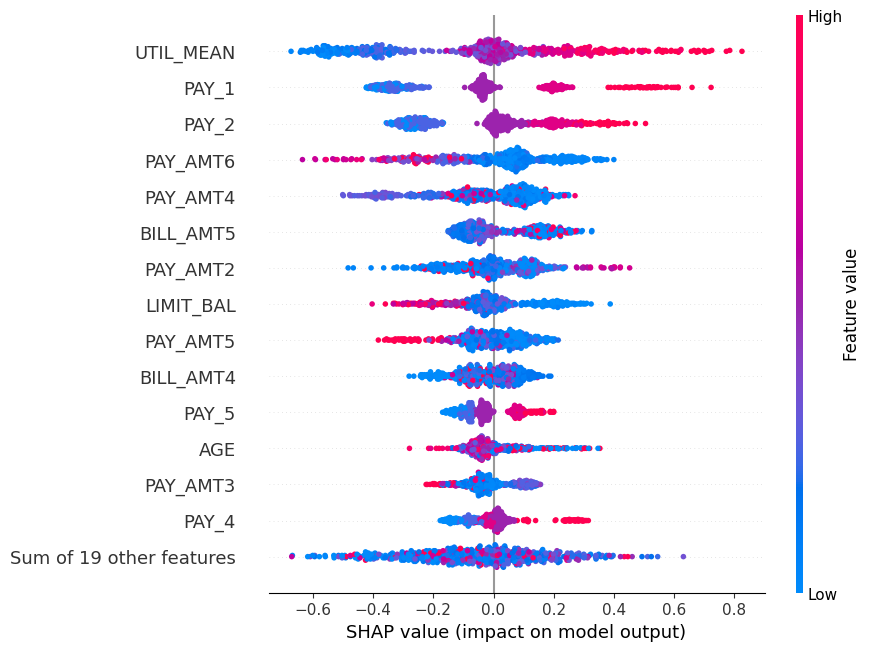

In [8]:
shap.plots.beeswarm(sv_cal, max_display=15)

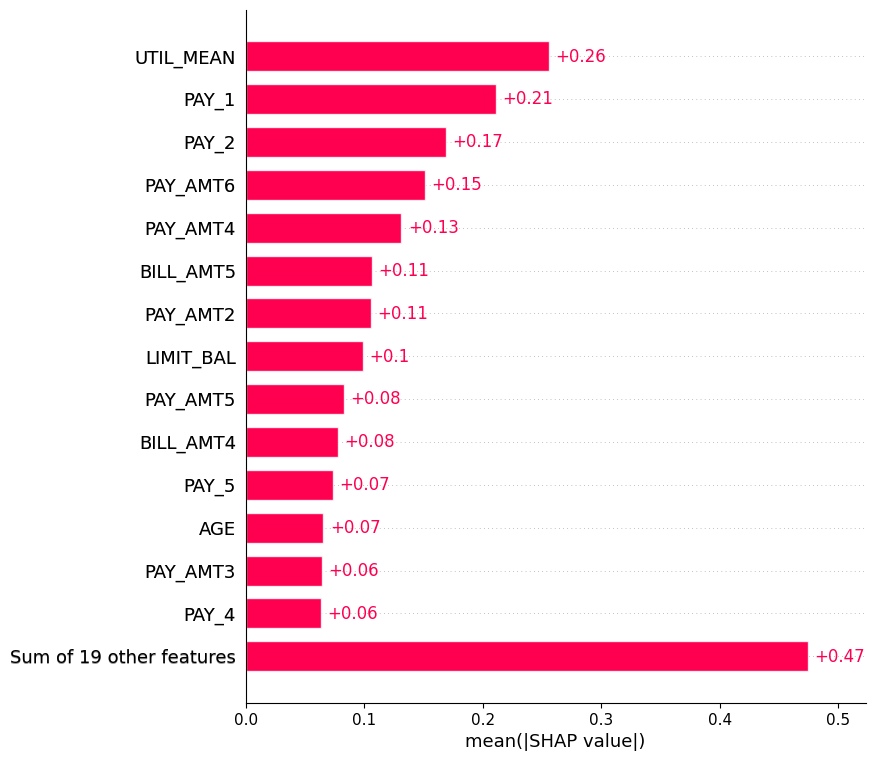

In [9]:
shap.plots.bar(sv_cal, max_display=15)

Dependence plot được trình bày cho ba đặc trưng có mức độ quan trọng cao nhất; tham số `color=sv_cal` cho phép SHAP tự động chọn biến tương tác mạnh nhất.

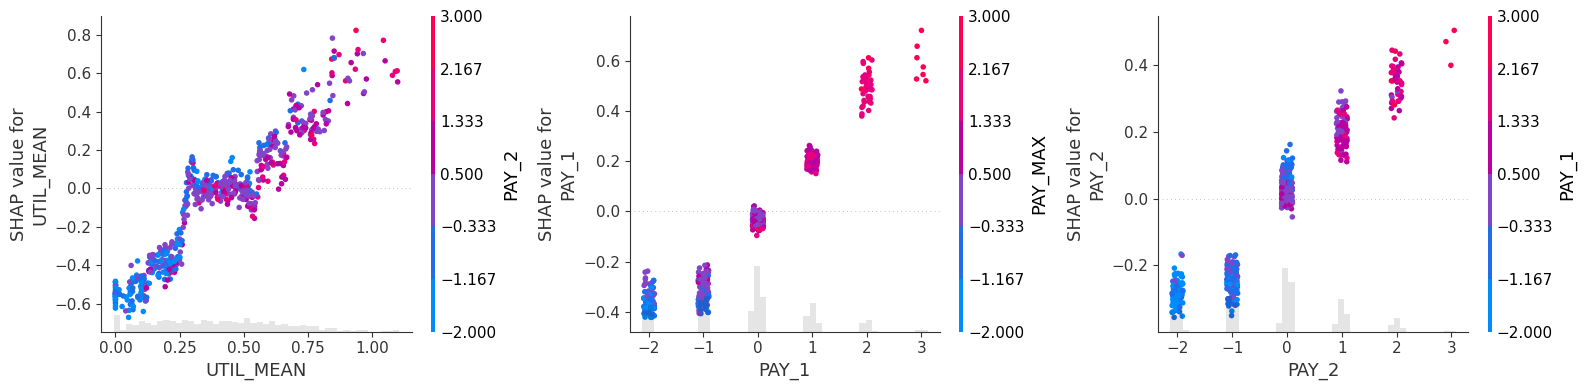

In [10]:
top3 = np.argsort(-np.abs(sv_cal.values).mean(0))[:3]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, j in zip(axes, top3):
    shap.plots.scatter(sv_cal[:, j], color=sv_cal, ax=ax, show=False)
plt.tight_layout()
plt.show()

## 7. SHAP theo nhóm đặc trưng

Do các đặc trưng `PAY_x` và `BILL_AMTx` có tương quan cao, SHAP phân bổ đóng góp giữa chúng không ổn định; tổng hợp theo nhóm đặc trưng cho kết quả ổn định hơn và là cơ sở để xây dựng reason codes.

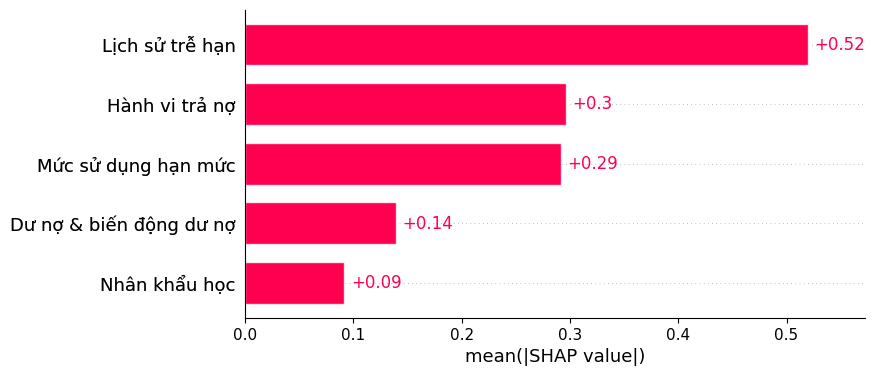

,đặc trưng
Dư nợ & biến động dư nợ,"BILL_AMT1, BILL_AMT2, BILL_AMT3, BILL_AMT4, BI..."
Hành vi trả nợ,"PAY_AMT1, PAY_AMT2, PAY_AMT3, PAY_AMT4, PAY_AM..."
Lịch sử trễ hạn,"PAY_6, PAY_5, PAY_4, PAY_3, PAY_2, PAY_1, PAY_MAX"
Mức sử dụng hạn mức,"LIMIT_BAL, UTIL_MEAN"
Nhân khẩu học,"EDUCATION_0, EDUCATION_1, EDUCATION_2, EDUCATI..."


In [11]:
grouped = group_shap(sv_cal)
assert np.allclose(sv_cal.base_values + grouped.sum(1), logit(pd_explain), atol=1e-3)

sv_group = shap.Explanation(grouped.values, sv_cal.base_values, feature_names=list(grouped.columns))
shap.plots.bar(sv_group)
groups = pd.Series(feature_to_group(sv.feature_names))
groups.index.to_series().groupby(groups).agg(", ".join).to_frame("đặc trưng")

## 8. Giải thích cục bộ: ba trường hợp đại diện

Ba trường hợp được chọn từ tập Explain: PD thấp nhất (Duyệt), PD cao nhất (Từ chối), và PD gần ngưỡng `THRESHOLD` nhất (Ca biên). Biểu đồ waterfall được trình bày trên thang điểm: $E[f(X)]$ là điểm nền, $f(x)$ là điểm của khách hàng (chưa clip) — đúng định dạng dự kiến hiển thị trên demo Streamlit. Trên thang điểm, thanh màu đỏ thể hiện phần tăng điểm (giảm rủi ro), thanh màu xanh thể hiện phần bị trừ điểm.

In [12]:
cases = {
    "Duyệt": int(np.argmin(pd_explain)),
    "Từ chối": int(np.argmax(pd_explain)),
    "Ca biên": int(np.argmin(np.abs(pd_explain - THRESHOLD))),
}
pd.DataFrame({
    name: {"PD": pd_explain[i], "điểm": pd_to_score(pd_explain[i]), "nhãn thật": int(y_explain.iloc[i])}
    for name, i in cases.items()
}).T

,PD,điểm,nhãn thật
Duyệt,0.0151,607.5926,1.0000
Từ chối,0.8565,435.5741,1.0000
Ca biên,0.3003,511.5235,0.0000


=== Duyệt: PD = 0.015, điểm = 607.6


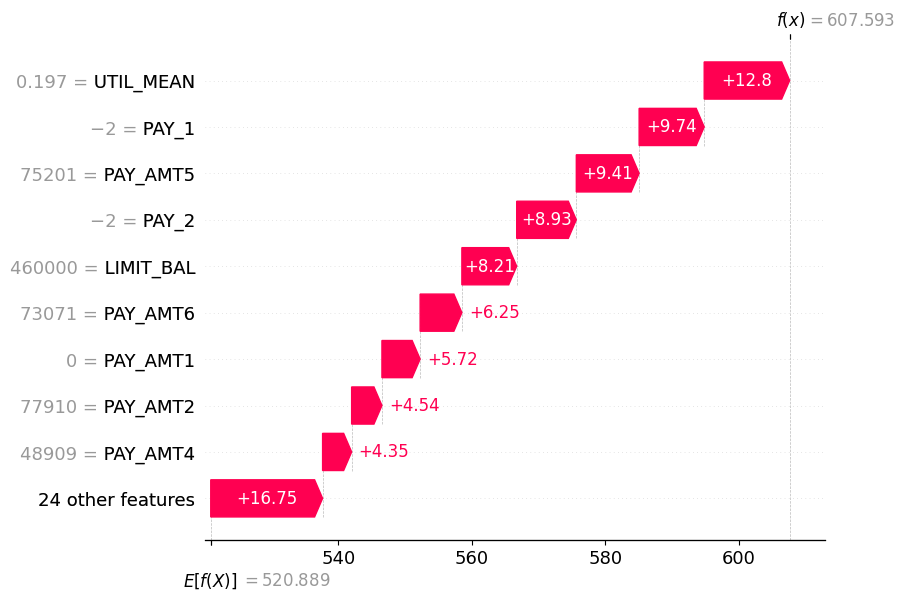

=== Từ chối: PD = 0.857, điểm = 435.6


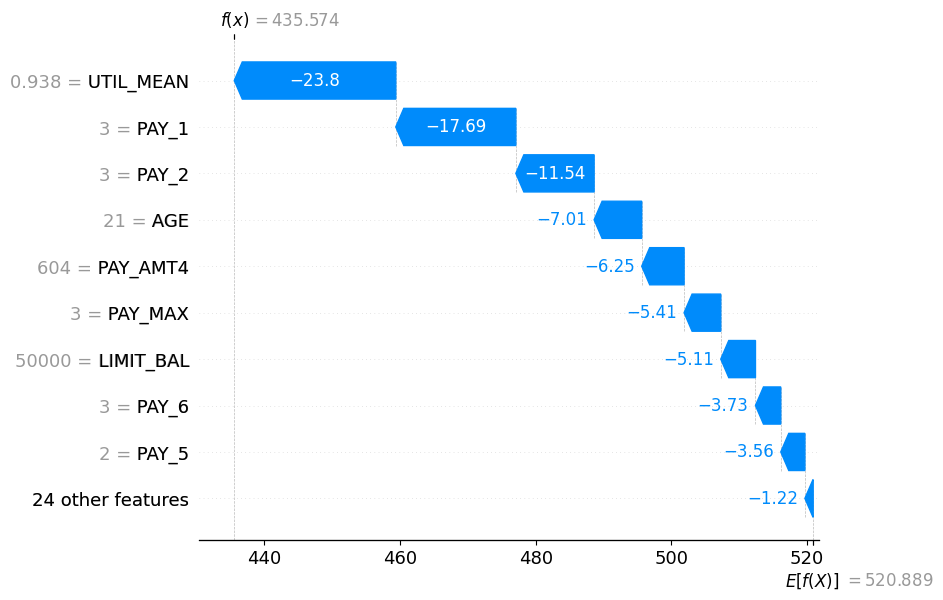

=== Ca biên: PD = 0.300, điểm = 511.5


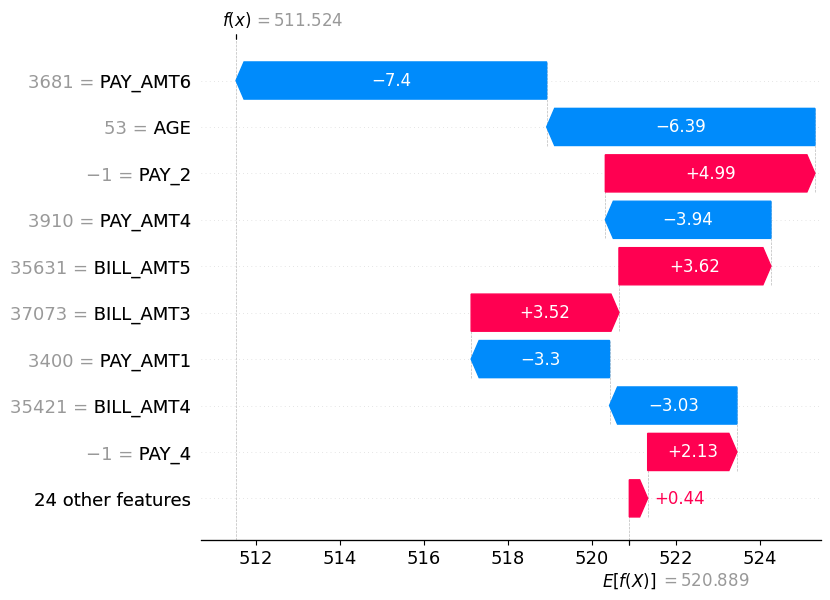

In [13]:
for name, i in cases.items():
    print(f"=== {name}: PD = {pd_explain[i]:.3f}, điểm = {pd_to_score(pd_explain[i]):.1f}")
    shap.plots.waterfall(sv_pts[i], max_display=10)

### Reason codes

Reason codes được xác định là ba nhóm đặc trưng có $\phi > 0$ lớn nhất (làm tăng rủi ro), hiển thị dưới dạng điểm bị trừ. Bảng chi tiết cho thấy tổng điểm nền và điểm các nhóm khớp đúng với điểm cuối cùng.

In [14]:
base_points = float(OFFSET - FACTOR * sv_cal.base_values[0])
rows = {}
for name, i in cases.items():
    pts = shap_to_points(grouped.iloc[i])
    rows[name] = {"Điểm nền": base_points, **pts.to_dict(),
                  "Tổng (chưa clip)": base_points + pts.sum(),
                  "pd_to_score": pd_to_score(pd_explain[i], clip=None)}
    print(f"{name:8s} →", reason_codes(grouped.iloc[i]) or "không có nhóm nào làm tăng rủi ro")
pd.DataFrame(rows).round(1)

Duyệt    → không có nhóm nào làm tăng rủi ro
Từ chối  → [('Lịch sử trễ hạn', -45.3), ('Mức sử dụng hạn mức', -28.9), ('Nhân khẩu học', -10.0)]
Ca biên  → [('Hành vi trả nợ', -13.1), ('Nhân khẩu học', -9.2)]


,Duyệt,Từ chối,Ca biên
Điểm nền,520.9000,520.9000,520.9000
Dư nợ & biến động dư nợ,2.8000,1.0000,2.9000
Hành vi trả nợ,31.7000,-2.1000,-13.1000
Lịch sử trễ hạn,28.6000,-45.3000,9.9000
Mức sử dụng hạn mức,21.0000,-28.9000,0.1000
Nhân khẩu học,2.6000,-10.0000,-9.2000
Tổng (chưa clip),607.6000,435.6000,511.5000
pd_to_score,607.6000,435.6000,511.5000


## 9. LinearExplainer cho Logistic Regression

Với masker Independent, giá trị SHAP được tính theo công thức $\phi_j = \beta_j (x_j - \mathbb{E}[x_j])$ trên thang đã chuẩn hóa, có tổng bằng `decision_function` (log-odds). Kỳ vọng $\mathbb{E}[x]$ được ước lượng từ 100 dòng dữ liệu nền lấy từ tập Train (giá trị mặc định tối đa của `Independent`).

khớp công thức beta*(x - mean): True
additivity với decision_function: True


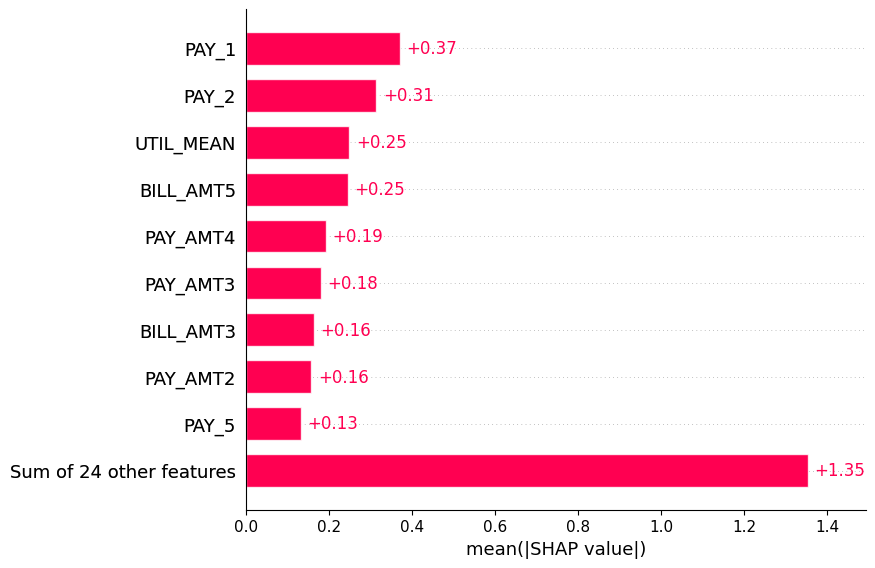

In [15]:
logreg, prep_lr = pipe_lr[-1], pipe_lr[:-1]
X_bg_lr = prep_lr.transform(shap.sample(X_train, 100, random_state=SEED))
X_explain_lr = prep_lr.transform(X_explain)

lin_explainer = shap.LinearExplainer(logreg, shap.maskers.Independent(X_bg_lr, max_samples=100))
sv_lr = lin_explainer(X_explain_lr)

manual = logreg.coef_[0] * (X_explain_lr.values - X_bg_lr.values.mean(0))
print("khớp công thức beta*(x - mean):", np.allclose(sv_lr.values, manual, atol=1e-8))
print("additivity với decision_function:",
      np.allclose(sv_lr.base_values + sv_lr.values.sum(1), logreg.decision_function(X_explain_lr), atol=1e-6))
shap.plots.bar(sv_lr, max_display=10)

Mức độ đồng thuận theo nhóm đặc trưng giữa XGBoost và Logistic Regression được so sánh bằng mean |SHAP| trên thang log-odds, chuẩn hóa theo tổng.

In [16]:
def group_importance(sv_):
    imp = group_shap(sv_).abs().mean()
    return imp / imp.sum()

pd.DataFrame({"XGBoost": group_importance(sv_cal), "Logistic": group_importance(sv_lr)}).sort_values("XGBoost", ascending=False)

,XGBoost,Logistic
Lịch sử trễ hạn,0.3883,0.4796
Hành vi trả nợ,0.2215,0.1446
Mức sử dụng hạn mức,0.2179,0.1782
Dư nợ & biến động dư nợ,0.1039,0.0430
Nhân khẩu học,0.0684,0.1546


## 10. Đối chiếu chéo với KernelExplainer

`KernelExplainer` với `link="logit"` áp dụng trên `predict_proba` ước lượng giá trị SHAP interventional trên thang margin, do đó được đối chiếu với `TreeExplainer(..., feature_perturbation="interventional")` sử dụng cùng dữ liệu nền. Do chi phí tính toán cao, phép đối chiếu chỉ được thực hiện trên 10 dòng và không được sử dụng trong demo.

In [17]:
bg = shap.sample(prep.transform(X_train), 50, random_state=SEED)
rows_k = X_explain_t.iloc[:10]

tree_int = shap.TreeExplainer(model, data=bg, feature_perturbation="interventional")
phi_tree = tree_int.shap_values(rows_k)

kernel = shap.KernelExplainer(lambda Z: model.predict_proba(Z)[:, 1], bg, link="logit")
t0 = time.perf_counter()
phi_kernel = kernel.shap_values(rows_k, nsamples=1000, silent=True)
t_kernel = (time.perf_counter() - t0) / len(rows_k)

diff = np.abs(phi_kernel - phi_tree)
print(f"tương quan Kernel vs Tree(interventional): {np.corrcoef(phi_kernel.ravel(), phi_tree.ravel())[0, 1]:.4f}")
print(f"|Δφ| trung bình = {diff.mean():.4f}, lớn nhất = {diff.max():.4f} (thang margin)")
print(f"Kernel: {t_kernel:.2f} s/dòng")

tương quan Kernel vs Tree(interventional): 0.9768
|Δφ| trung bình = 0.0216, lớn nhất = 0.1809 (thang margin)
Kernel: 0.33 s/dòng


Phương pháp path-dependent (sử dụng trong demo) và interventional khác nhau về định nghĩa $f_S(x)$; tuy nhiên thứ hạng mức độ quan trọng toàn cục giữa hai phương pháp được kỳ vọng tương đồng:

In [18]:
phi_int_all = tree_int.shap_values(X_explain_t)
rank = pd.DataFrame({
    "path_dependent": np.abs(sv.values).mean(0),
    "interventional": np.abs(phi_int_all).mean(0),
}, index=sv.feature_names)
print("Spearman:", round(rank.corr(method="spearman").iloc[0, 1], 3))
rank.sort_values("path_dependent", ascending=False).head(10)

Spearman: 0.988


,path_dependent,interventional
UTIL_MEAN,0.3378,0.3806
PAY_1,0.2785,0.2440
PAY_2,0.2227,0.2410
PAY_AMT6,0.1992,0.2502
PAY_AMT4,0.1736,0.2062
BILL_AMT5,0.1404,0.1698
PAY_AMT2,0.1393,0.1485
LIMIT_BAL,0.1305,0.1525
PAY_AMT5,0.1094,0.1175
BILL_AMT4,0.1030,0.1160


## 11. Chuẩn hóa shape đầu ra với RandomForest và thời gian tính toán

SHAP của RandomForest (scikit-learn) trả về shape `(n, M, 2)` trên thang xác suất; hàm `positive_class()` chuẩn hóa đầu ra này về shape `(n, M)` tương ứng với lớp vỡ nợ.

In [19]:
rf = RandomForestClassifier(n_estimators=50, max_depth=6, random_state=SEED, n_jobs=-1).fit(prep.transform(X_train), y_train)
sv_rf_raw = shap.TreeExplainer(rf)(X_explain_t.iloc[:50])
sv_rf = positive_class(sv_rf_raw)
print("RF raw:", sv_rf_raw.values.shape, "→ lớp vỡ nợ:", sv_rf.values.shape)
print("additivity (thang xác suất):",
      np.allclose(sv_rf.base_values + sv_rf.values.sum(1), rf.predict_proba(X_explain_t.iloc[:50])[:, 1], atol=1e-6))

RF raw: (50, 33, 2) → lớp vỡ nợ: (50, 33)
additivity (thang xác suất): True


In [20]:
def per_row_ms(fn, X_, n=50):
    t0 = time.perf_counter()
    for i in range(n):
        fn(X_.iloc[[i]])
    return (time.perf_counter() - t0) / n * 1000

print(f"TreeExplainer (path-dependent): {per_row_ms(explainer, X_explain_t):.1f} ms/khách hàng")
print(f"LinearExplainer               : {per_row_ms(lin_explainer, X_explain_lr):.1f} ms/khách hàng")
print(f"KernelExplainer               : {t_kernel * 1000:.0f} ms/khách hàng")

TreeExplainer (path-dependent): 16.1 ms/khách hàng
LinearExplainer               : 0.6 ms/khách hàng
KernelExplainer               : 333 ms/khách hàng


## 12. Kết luận

- Luồng TreeExplainer → nhân hệ số Platt $a$ → quy đổi sang điểm PDO bảo toàn tính cộng tính ở cả ba thang giá trị (margin, logit(PD), điểm). Các phép kiểm tra tại mục 5 và mục 7 được xác định là bộ kiểm thử tối thiểu cần giữ lại khi chuyển sang `src/`.
- SHAP theo nhóm đặc trưng và reason codes được tính trực tiếp từ giá trị SHAP đã hiệu chuẩn; tổng điểm nền và điểm các nhóm khớp đúng với điểm cuối cùng (trước khi áp dụng clip).
- LinearExplainer (Independent) cho kết quả khớp chính xác với công thức $\beta_j(x_j - \bar x_j)$. KernelExplainer cho kết quả gần với TreeExplainer interventional nhưng có thời gian tính toán chậm hơn nhiều bậc, nên chỉ phù hợp cho mục đích đối chiếu.
- RandomForest yêu cầu chuẩn hóa shape đầu ra thông qua `positive_class()` và không tương thích trực tiếp với phương pháp hiệu chuẩn Platt trên margin.

**Định hướng tiếp theo:** Thay thế `load_data()` bằng dữ liệu thật và `make_prep()` bằng `src/features.py`; chuyển các hàm tại mục 4 vào `src/explain.py` và `src/scoring.py` kèm unit test; xác định danh sách nhóm đặc trưng chính thức (Tuần 2, T4) và ngưỡng quyết định (Tuần 3).